This notebook is in place to evaluate the learned value functions $Q_D$ and $Q_R$ on the LifeGate (v.1.0) domain. We want to compare how DeD (DQN) works in comparison to UncDeD (IQN). For this introspective analysis, we need to:
 1. define a Q-network (whether IQN or DQN), following `model.py`
 2. load in the trained weights for each of $Q_D$ and $Q_R$.
 3. Iterate through each state (x,y) in the 9x9 LifeGate grid and record the estimated Q-values. This will be a set of samples from UncDeD, a single sample (E[R]) in the case of DeD, for each action.
 4. Plot heatmap of the max value over the actions? 

In [366]:
import pickle
import os
import numpy as np
import pandas as pd

import torch

from matplotlib import cm
import matplotlib.pyplot as plt
import seaborn as sns

import itertools

plt.rcParams.update({'font.size': 20})

from model import IQN, DQN

In [418]:
uncded_pth = 'lifegate_ded_driftp4_fixedstart' #nope
# uncded_pth = 'lifegate_ded_p2' # YES
# uncded_pth = 'lifegate_ded_p2_smaller' # SORT OF
# uncded_pth = 'lifegate_ded_p2_contstate' # kind of
# uncded_pth = 'lifegate_ded_p4'  # nope
# uncded_pth = 'lifegate_ded_p4_contstate' # nope



ded_pth = 'lifegate_DQN_ded_driftp4_fixedstart' # nope
# ded_pth = 'lifegate_DQN_ded_p2'# YES
# ded_pth = 'lifegate_DQN_ded_p2_smaller'# SORT OF
# ded_pth = 'lifegate_DQN_ded_p2_contstate' # kind of
# ded_pth = 'lifegate_DQN_ded_p4'  # nope
# ded_pth = 'lifegate_DQN_ded_p4_contstate' # nope

In [421]:
# Initialize the Q_D and Q_R networks
state_size = (2,)
action_size = 5
layer_size = 32 #512
n_step = 1
seed=1
N = 8
drm='cvar'
duel=False
noisy=False
device='cpu'

iqn_d = IQN(state_size, action_size, layer_size, n_step, seed, N, drm=drm, dueling=duel, noisy=noisy, device=device).to(device)
iqn_r = IQN(state_size, action_size, layer_size, n_step, seed, N, drm=drm, dueling=duel, noisy=noisy, device=device).to(device)

dqn_d = DQN(state_size, action_size, layer_size, seed, dueling=duel, noisy=noisy, device=device).to(device)
dqn_r = DQN(state_size, action_size, layer_size, seed, dueling=duel, noisy=noisy, device=device).to(device)

In [422]:
# Load in the trained network parameters, set the models to .eval()

iqn_d.load_state_dict(torch.load(os.path.join("runs", uncded_pth, uncded_pth+'_Qd.pth')))
iqn_d.eval()
iqn_r.load_state_dict(torch.load(os.path.join("runs", uncded_pth, uncded_pth+'_Qr.pth')))
iqn_r.eval()

dqn_d.load_state_dict(torch.load(os.path.join("runs", ded_pth, ded_pth+'_Qd.pth')))
dqn_d.eval()
dqn_r.load_state_dict(torch.load(os.path.join("runs", ded_pth, ded_pth+'_Qr.pth')))
dqn_r.eval()

DQN(
  (head): Linear(in_features=2, out_features=32, bias=True)
  (ff_1): Linear(in_features=32, out_features=32, bias=True)
  (ff_2): Linear(in_features=32, out_features=5, bias=True)
)

In [423]:
iqn_d.eta = 0.001
iqn_r.eta = 0.001

In [6]:
VaR_thresh = 0.1
num_samples = 1000
VaR_cutoff = round(VaR_thresh*num_samples)

In [7]:
scr_w, scr_h = 10, 10

states = itertools.product(range(scr_w), range(scr_h))

In [8]:
scr_w, scr_h = 10, 10

states = itertools.product(range(scr_w), range(scr_h))

full_D_max = np.zeros((scr_w, scr_h))
full_R_max = np.zeros((scr_w, scr_h))
drm_D_max = np.zeros((scr_w, scr_h))
drm_R_max = np.zeros((scr_w, scr_h))
cvar_D_max = np.zeros((scr_w, scr_h))
cvar_R_max = np.zeros((scr_w, scr_h))

full_D_med = np.zeros((scr_w, scr_h))
full_R_med = np.zeros((scr_w, scr_h))
drm_D_med = np.zeros((scr_w, scr_h))
drm_R_med = np.zeros((scr_w, scr_h))
cvar_D_med = np.zeros((scr_w, scr_h))
cvar_R_med = np.zeros((scr_w, scr_h))

full_D_min = np.zeros((scr_w, scr_h))
full_R_min = np.zeros((scr_w, scr_h))
drm_D_min = np.zeros((scr_w, scr_h))
drm_R_min = np.zeros((scr_w, scr_h))
cvar_D_min = np.zeros((scr_w, scr_h))
cvar_R_min = np.zeros((scr_w, scr_h))

full_DQN_D_max = np.zeros((scr_w, scr_h))
full_DQN_R_max = np.zeros((scr_w, scr_h))

full_DQN_D_med = np.zeros((scr_w, scr_h))
full_DQN_R_med = np.zeros((scr_w, scr_h))

full_DQN_D_min = np.zeros((scr_w, scr_h))
full_DQN_R_min = np.zeros((scr_w, scr_h))

# Loop through all states
for state in states:
    
    # Get state tuple into numpy -> torch format
    inp_state = torch.from_numpy(np.array(state).reshape((1,-1))).float().to(device)

    # Pass state through the IQN and DQN networks
    iqn_d_vals, taus_d = iqn_d.forward(inp_state, num_samples, use_drm=False)
    iqn_d_vals_drm, taus_d_drm = iqn_d.forward(inp_state, num_samples, use_drm=True)
    
    iqn_r_vals, taus_r = iqn_r.forward(inp_state, num_samples, use_drm=False)
    iqn_r_vals_drm, taus_r_drm = iqn_r.forward(inp_state, num_samples, use_drm=True)
    
    dqn_d_vals = dqn_d.forward(inp_state)
    dqn_r_vals = dqn_r.forward(inp_state)
    
    dqn_d_vals = dqn_d_vals.detach().squeeze().numpy()
    dqn_r_vals = dqn_r_vals.detach().squeeze().numpy()
    
    # Get the CVaR for IQN_D and IQN_R... First get Tensors to Numpy
    iqn_d_vals = np.sort(iqn_d_vals.detach().squeeze().numpy(), axis=0) # Sort the values for each action (for CVaR computation)
    iqn_d_vals_drm = iqn_d_vals_drm.detach().squeeze().numpy()
    iqn_d_vals_var = iqn_d_vals[:VaR_cutoff,:]
    
    iqn_r_vals = np.sort(iqn_r_vals.detach().squeeze().numpy(), axis=0)  # Sort the values for each action (for CVaR computation)  
    iqn_r_vals_drm = iqn_r_vals_drm.detach().squeeze().numpy()
    iqn_r_vals_var = iqn_r_vals[:VaR_cutoff,:]
    
    # Take means of each action distribution
    mean_d_vals = np.mean(iqn_d_vals, axis=0)
    mean_d_vals_drm = np.mean(iqn_d_vals_drm, axis=0)
    mean_d_vals_var = np.mean(iqn_d_vals_var, axis=0)
    
    mean_r_vals = np.mean(iqn_r_vals, axis=0)
    mean_r_vals_drm = np.mean(iqn_r_vals_drm, axis=0)
    mean_r_vals_var = np.mean(iqn_r_vals_var, axis=0)
    
    # Select Action Value for each state according to the mean... 
    # We will have three ways of choosing this (over the actions): Max Value, Median Value, Min Value (pessimistic?)
    full_D_max[state[0], state[1]] = max(mean_d_vals)
    full_R_max[state[0], state[1]] = max(mean_r_vals)
    drm_D_max[state[0], state[1]] = max(mean_d_vals_drm)
    drm_R_max[state[0], state[1]] = max(mean_r_vals_drm)
    cvar_D_max[state[0], state[1]] = max(mean_d_vals_var)
    cvar_R_max[state[0], state[1]] = max(mean_r_vals_var)
    
    full_D_med[state[0], state[1]] = np.median(mean_d_vals)
    full_R_med[state[0], state[1]] = np.median(mean_r_vals)
    drm_D_med[state[0], state[1]] = np.median(mean_d_vals_drm)
    drm_R_med[state[0], state[1]] = np.median(mean_r_vals_drm)
    cvar_D_med[state[0], state[1]] = np.median(mean_d_vals_var)
    cvar_R_med[state[0], state[1]] = np.median(mean_r_vals_var)
    
    full_D_min[state[0], state[1]] = min(mean_d_vals)
    full_R_min[state[0], state[1]] = min(mean_r_vals)
    drm_D_min[state[0], state[1]] = min(mean_d_vals_drm)
    drm_R_min[state[0], state[1]] = min(mean_r_vals_drm)
    cvar_D_min[state[0], state[1]] = min(mean_d_vals_var)
    cvar_R_min[state[0], state[1]] = min(mean_r_vals_var)
    
    full_DQN_D_max[state[0], state[1]] = max(dqn_d_vals)
    full_DQN_R_max[state[0], state[1]] = max(dqn_r_vals)
    
    full_DQN_D_med[state[0], state[1]] = np.median(dqn_d_vals)
    full_DQN_R_med[state[0], state[1]] = np.median(dqn_r_vals)
    
    full_DQN_D_max[state[0], state[1]] = min(dqn_d_vals)
    full_DQN_R_max[state[0], state[1]] = min(dqn_r_vals)

### NOW VISUALIZE THESE WITH HEATMAPS!

In [40]:
# Get the values we want from the networks and put them into tables like below...

# q_table = np.zeros((10, 10, 5))
# q_d = np.zeros_like(q_table)
# q_r = np.zeros_like(q_table)

In [41]:
# for i in range(10):
#     for j in range(10):
#         for a in range(5):
#             key = tuple([j, i, a])
#             try:
#                 q_table[i,j,a] = ai.q[key]
#                 q_d[i,j,a] = ai_d.q[key]
#                 q_r[i,j,a] = ai_r.q[key]
#             except:
#                 pass

In [2]:
# Plotting utilities for annotating the images

# RGB colors
WHITE = np.array((255, 255, 255, 255))/255
BLACK = np.array((0, 0, 0, 255))/255
RED = np.array((255, 0, 0, 255))/255
BLUE = np.array((0, 100, 255, 255))/255
GREEN = np.array((0, 255, 0, 255))/255
WALL = np.array((80, 80, 80, 255))/255
YELLOW = np.array((255, 255, 0, 255))/255
YL_RD = np.array((255, 165, 0, 255))/255

# Positions of important aspects of the Lifegate game
scr_w, scr_h = 10, 10
barriers = [[0, 0], [1, 0], [2, 0], [3, 0], [4, 0], [1, 5], [2, 5], [3, 5], [4, 5]]
lifes = [[5,0], [6, 0], [7, 0]]
deaths = [[scr_w - 1, k] for k in range(scr_h)]+ [[8,0]]
deadends = [[x, y] for x in range(scr_w // 2 + 1, scr_w - 1) for y in range(3*scr_w // 4, scr_w)]
risk_zone = [[x, y] for x in range(scr_w//2, scr_w-1) for y in range(scr_w//2, scr_w) if [x, y] not in deadends]
positions = [[2, 9]]

def annotate_image(img):
    for wall in barriers:
        img[wall[1],wall[0],:] = WALL
    for life in lifes:
        img[life[1], life[0], :] = BLUE
    for death in deaths:
        img[death[1], death[0], :] = RED
    return img

def build_lg_image(img):
    img = annotate_image(img)
    for de in deadends:
        img[de[1], de[0], :] = YL_RD # YELLOW # YL_RD
#     for pos in positions:
#         img[pos[1], pos[0], :] = WHITE
    for rz in risk_zone:
        img[rz[1], rz[0], :] = YL_RD # YELLOW
        
    return img

cmap = plt.cm.RdBu
norm = plt.Normalize(-1., 1.)

## Plot the Q tables of the agent (`q_table`) and those generated for the D-Network (`q_d`) and R-Network (`q_r`)

### Full Value Distribution (D-Network)

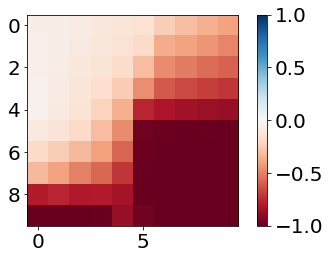

In [43]:
plt.figure()
# plt.imshow(np.max(q_table,axis=-1),vmin=-1., vmax=1., cmap='RdBu')
plt.imshow(full_D_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.tight_layout()
plt.show()
# plt.savefig("lifegate_q_table.pdf", dpi=300)
plt.close()

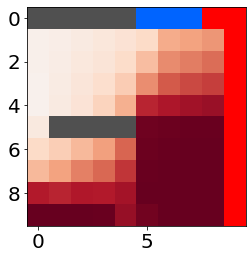

In [44]:
plt.figure()
# temp = np.max(q_table, axis=-1)
temp = full_D_med
img = cmap(norm(temp))
img = annotate_image(img)
plt.imshow(img)
plt.tight_layout()
plt.show()
# plt.savefig("annotated_lifegate_q_table.pdf", dpi=300)
plt.close()

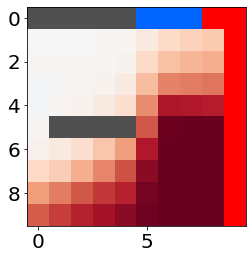

In [45]:
plt.figure()
# temp = np.max(q_table, axis=-1)
temp = full_DQN_D_med
img = cmap(norm(temp))
img = annotate_image(img)
plt.imshow(img)
plt.tight_layout()
plt.show()
# plt.savefig("annotated_lifegate_q_table.pdf", dpi=300)
plt.close()

### DRM version (D-Network)

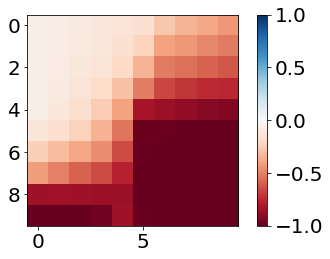

In [46]:
plt.figure()
# plt.imshow(np.max(q_d, axis=-1),vmin=-1., vmax=1., cmap='RdBu')
plt.imshow(drm_D_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.tight_layout()
plt.show()
# plt.savefig("lifegate_q_d.pdf")
plt.close()

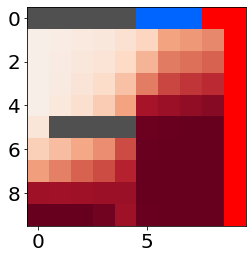

In [47]:
plt.figure()
# temp = np.max(q_d, axis=-1)
temp = drm_D_med
img = cmap(norm(temp))
img = annotate_image(img)
im = plt.imshow(img)
plt.tight_layout()
plt.show()
# plt.savefig("annotated_lifegate_q_d.pdf", dpi=300)
plt.close()

### CVaR version (D-Network)

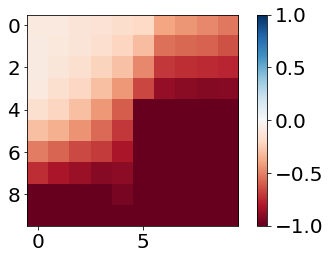

In [48]:
plt.figure()
# plt.imshow(np.max(q_d, axis=-1),vmin=-1., vmax=1., cmap='RdBu')
plt.imshow(cvar_D_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.tight_layout()
plt.show()
# plt.savefig("lifegate_q_d.pdf")
plt.close()

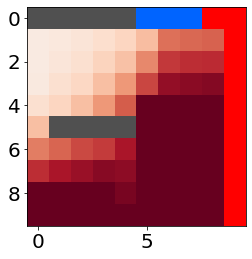

In [49]:
plt.figure()
# temp = np.max(q_d, axis=-1)
temp = cvar_D_med
img = cmap(norm(temp))
img = annotate_image(img)
im = plt.imshow(img)
plt.tight_layout()
plt.show()
# plt.savefig("annotated_lifegate_q_d.pdf", dpi=300)
plt.close()

### Full Distribution (R-Network)

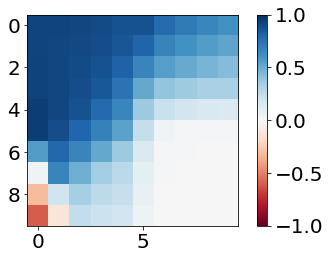

In [50]:
plt.figure()
# plt.imshow(np.max(q_r, axis=-1),vmin=-1., vmax=1., cmap='RdBu')
plt.imshow(full_R_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.tight_layout()
plt.show()
# plt.savefig("lifegate_q_r.pdf", dpi=300)
plt.close()

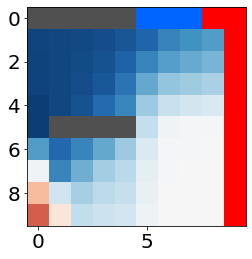

In [51]:
plt.figure()
# temp = np.max(q_r, axis=-1)
temp = full_R_med
img = cmap(norm(temp))
img = annotate_image(img)
plt.imshow(img)
plt.tight_layout()
plt.show()
# plt.savefig("annotated_lifegate_q_r.pdf", dpi=300)
plt.close()

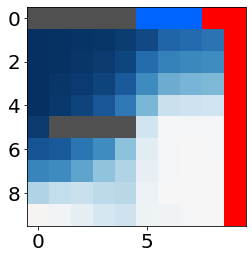

In [52]:
plt.figure()
# temp = np.max(q_table, axis=-1)
temp = full_DQN_R_med
img = cmap(norm(temp))
img = annotate_image(img)
plt.imshow(img)
plt.tight_layout()
plt.show()
# plt.savefig("annotated_lifegate_q_table.pdf", dpi=300)
plt.close()

### DRM Distribution (R-Network)

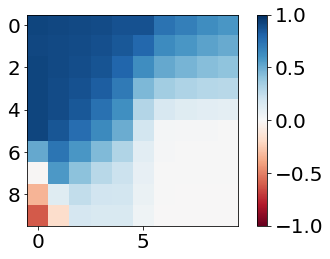

In [53]:
plt.figure()
# plt.imshow(np.max(q_r, axis=-1),vmin=-1., vmax=1., cmap='RdBu')
plt.imshow(drm_R_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.tight_layout()
plt.show()
# plt.savefig("lifegate_q_r.pdf", dpi=300)
plt.close()

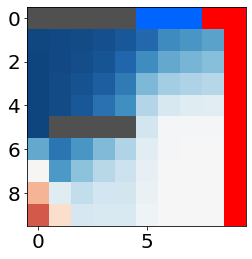

In [54]:
plt.figure()
# temp = np.max(q_r, axis=-1)
temp = drm_R_med
img = cmap(norm(temp))
img = annotate_image(img)
plt.imshow(img)
plt.tight_layout()
plt.show()
# plt.savefig("annotated_lifegate_q_r.pdf", dpi=300)
plt.close()

### CVaR Distribution (R-Network)

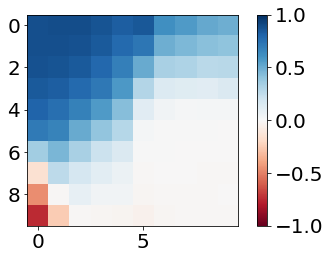

In [55]:
plt.figure()
# plt.imshow(np.max(q_r, axis=-1),vmin=-1., vmax=1., cmap='RdBu')
plt.imshow(cvar_R_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.tight_layout()
plt.show()
# plt.savefig("lifegate_q_r.pdf", dpi=300)
plt.close()

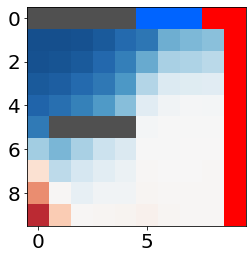

In [56]:
plt.figure()
# temp = np.max(q_r, axis=-1)
temp = cvar_R_med
img = cmap(norm(temp))
img = annotate_image(img)
plt.imshow(img)
plt.tight_layout()
plt.show()
# plt.savefig("annotated_lifegate_q_r.pdf", dpi=300)
plt.close()

In [11]:
trajectory_x = [9, 9, 9, 9, 9, 8, 8, 7, 7, 6, 6, 5, 4, 3, 2, 1, 0, 0, 0, 0]
trajectory_y = [1, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

In [98]:
traj1b_x = [9, 9, 9, 9, 9, 8, 8, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
traj1b_y = [1, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 6, 7, 8, 9, 9, 9, 9, 9]

In [99]:
traj2_x = [9, 9, 9, 9, 9, 8, 8, 7, 6, 5, 4, 4, 3, 3, 2, 2, 2, 1, 1, 0, 0, 0, 0]
traj2_y = [1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 1, 1, 2, 2, 3, 4, 4, 5, 5, 5, 5, 5]

In [100]:
traj3_x = [9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 7, 7, 6, 5, 4, 3, 2, 1, 0, 0, 0, 0]
traj3_y = [1, 1, 1, 1, 2, 3, 4, 4, 5, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]

In [101]:
traj3b_x = [9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
traj3b_y = [1, 1, 1, 1, 2, 2, 3, 3, 3, 4, 5, 6, 7, 8, 9, 9, 9, 9, 9, 9, 9, 9]

In [102]:
window_size = 5

cumsum_x = np.cumsum(np.insert(trajectory_x, 0, 0))
ma_x = (cumsum_x[window_size:] - cumsum_x[:-window_size]) / window_size

cumsum_y = np.cumsum(np.insert(trajectory_y, 0, 0))
ma_y = (cumsum_y[window_size:] - cumsum_y[:-window_size]) / window_size

cumsum1b_x = np.cumsum(np.insert(traj1b_x, 0, 0))
ma1b_x = (cumsum1b_x[window_size:] - cumsum1b_x[:-window_size]) / window_size

cumsum1b_y = np.cumsum(np.insert(traj1b_y, 0, 0))
ma1b_y = (cumsum1b_y[window_size:] - cumsum1b_y[:-window_size]) / window_size

cumsum2_x = np.cumsum(np.insert(traj2_x, 0, 0))
ma2_x = (cumsum2_x[window_size:] - cumsum2_x[:-window_size]) / window_size

cumsum2_y = np.cumsum(np.insert(traj2_y, 0, 0))
ma2_y = (cumsum2_y[window_size:] - cumsum2_y[:-window_size]) / window_size

cumsum3_x = np.cumsum(np.insert(traj3_x, 0, 0))
ma3_x = (cumsum3_x[window_size:] - cumsum3_x[:-window_size]) / window_size

cumsum3_y = np.cumsum(np.insert(traj3_y, 0, 0))
ma3_y = (cumsum3_y[window_size:] - cumsum3_y[:-window_size]) / window_size

cumsum3b_x = np.cumsum(np.insert(traj3b_x, 0, 0))
ma3b_x = (cumsum3b_x[window_size:] - cumsum3b_x[:-window_size]) / window_size

cumsum3b_y = np.cumsum(np.insert(traj3b_y, 0, 0))
ma3b_y = (cumsum3b_y[window_size:] - cumsum3b_y[:-window_size]) / window_size

In [103]:
def interpolate_vector(data, factor):
    n = len(data)
    # Interpolation points
    x = np.linspace(0, n-1, (n-1)*factor + 1)
    xp = np.arange(n)
    return np.interp(x, xp, np.asarray(data))

In [104]:
ma_int_x = interpolate_vector(ma_x, 10)
ma_int_y = interpolate_vector(ma_y, 10)
ma1b_int_x = interpolate_vector(ma1b_x, 10)
ma1b_int_y = interpolate_vector(ma1b_y, 10)
ma2_int_x = interpolate_vector(ma2_x, 10)
ma2_int_y = interpolate_vector(ma2_y, 10)
ma3_int_x = interpolate_vector(ma3_x, 10)
ma3_int_y = interpolate_vector(ma3_y, 10)
ma3b_int_x = interpolate_vector(ma3b_x, 10)
ma3b_int_y = interpolate_vector(ma3b_y, 10)

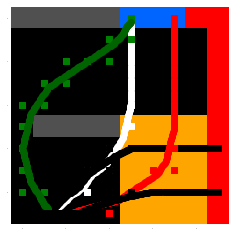

In [105]:
# Create Life-Gate Image
plt.figure()
lg_img = np.zeros((10,10,4))
lg_img[...,-1]=1
lg_img = build_lg_image(lg_img)
plt.tight_layout()
plt.imshow(lg_img)
# plt.savefig("lifegate.pdf", dpi=300)
plt.scatter(trajectory_y, trajectory_x, c='white', marker='s')
plt.scatter(ma_int_y, ma_int_x, c='white', marker='o')
plt.scatter(traj1b_y, traj1b_x, c='black', marker='s')
plt.scatter(ma1b_int_y, ma1b_int_x, c='black', marker='o')
plt.scatter(traj2_y, traj2_x, c='green', marker='s')
plt.scatter(ma2_int_y, ma2_int_x, c='darkgreen', marker='o')
plt.scatter(traj3_y, traj3_x, c='red', marker='s')
plt.scatter(ma3_int_y, ma3_int_x, c='red', marker='o')
plt.scatter(traj3b_y, traj3b_x, c='black', marker='s')
plt.scatter(ma3b_int_y, ma3b_int_x, c='black', marker='o')
ax = plt.gca()
plt.setp(ax.spines.values(), alpha = 0)
# set both tick marks and tick labels to size 0
ax.tick_params(which = 'both', size = 0, labelsize = 0)
plt.show()

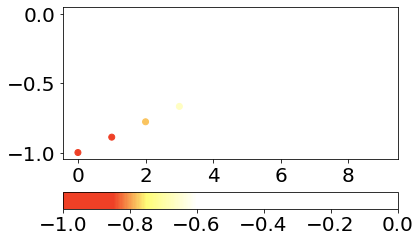

In [106]:
import matplotlib.colors

norm = matplotlib.colors.Normalize(-1, 0)
colors = [[norm(-1.0), "xkcd:tomato"],
          [norm(-0.85), "xkcd:tomato"],
          [norm(-0.75), "xkcd:custard"],
          [norm(-0.6), "white"],
          [norm(-0.4), "white"],
          [norm(0.0), "white"]]

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)


fig, ax=plt.subplots()
x = np.arange(10)
y = np.linspace(-1,0,10)
sc = ax.scatter(x,y, c=y, norm=norm, cmap=cmap)
fig.colorbar(sc, orientation="horizontal")
plt.show()

In [107]:
traj_1 = list(zip(ma_int_y, ma_int_x))
traj_2 = list(zip(ma2_int_y, ma2_int_x))
traj_3 = list(zip(ma3_int_y, ma3_int_x))
traj_1b = list(zip(ma1b_int_y, ma1b_int_x))
traj_3b = list(zip(ma3b_int_y, ma3b_int_x))

In [108]:
traj_values = []
for traj in [traj_1, traj_2, traj_3, traj_1b, traj_3b]:
    traj_value = {'iqn_d': [], 'iqn_r': [], 'dqn_d': [], 'dqn_r': [], 'iqn_comb': [], 'dqn_comb': []}
    for state in traj:
        # Get state tuple into numpy -> torch format
        inp_state = torch.from_numpy(np.array(state).reshape((1,-1))).float().to(device)

        # Pass state through the IQN and DQN networks
        iqn_d_vals, taus_d = iqn_d.forward(inp_state, num_samples, use_drm=False)
        iqn_r_vals, taus_r = iqn_r.forward(inp_state, num_samples, use_drm=False)

        dqn_d_vals = dqn_d.forward(inp_state)
        dqn_r_vals = dqn_r.forward(inp_state)

        dqn_d_vals = dqn_d_vals.detach().squeeze().numpy()
        dqn_r_vals = dqn_r_vals.detach().squeeze().numpy()

        # Get the CVaR for IQN_D and IQN_R... First get Tensors to Numpy
        iqn_d_vals = np.sort(iqn_d_vals.detach().squeeze().numpy(), axis=0) # Sort the values for each action (for CVaR computation)
        iqn_d_vals_var = iqn_d_vals[:VaR_cutoff,:]
        
        combined_vals = 0
        
        iqn_r_vals = np.sort(iqn_r_vals.detach().squeeze().numpy(), axis=0)  # Sort the values for each action (for CVaR computation)  
        iqn_r_vals_var = iqn_r_vals[:VaR_cutoff,:]
        
        comb_vals_iqn = np.mean([np.median(np.clip(iqn_d_vals_var, -1., 0.).mean(0)), np.median(np.clip(iqn_r_vals_var, 0., 1.).mean(0))-1.])
        comb_vals_dqn = np.mean([np.median(np.clip(dqn_d_vals, -1., 0.)), np.median(np.clip(dqn_r_vals, 0., 1.))-1.])
        
        traj_value['iqn_d'].append(np.median(iqn_d_vals_var.mean(0)))
        traj_value['iqn_r'].append(np.median(iqn_r_vals_var.mean(0)))
        traj_value['dqn_d'].append(np.median(dqn_d_vals))
        traj_value['dqn_r'].append(np.median(dqn_r_vals))
        traj_value['iqn_comb'].append(np.clip(comb_vals_iqn, -1., 0.))
        traj_value['dqn_comb'].append(np.clip(comb_vals_dqn, -1, 0.))

    traj_values.append(traj_value)
        

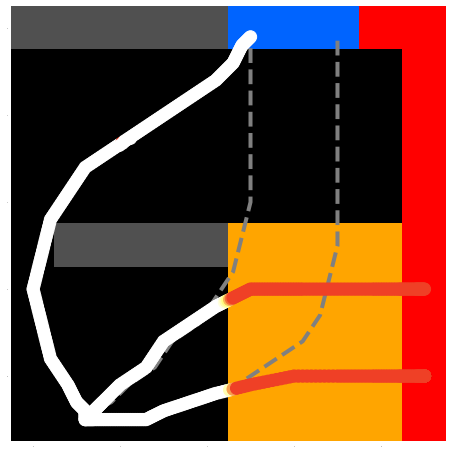

In [116]:
# Create Life-Gate Image
arch_type = 'dqn'
plt.figure(figsize=(8,8))
lg_img = np.zeros((10,10,4))
lg_img[...,-1]=1
lg_img = build_lg_image(lg_img)
plt.tight_layout()
plt.imshow(lg_img)
# plt.savefig("lifegate.pdf", dpi=300)

# plt.scatter(ma_int_y, ma_int_x, c=traj_values[0][f'{arch_type}_comb'], marker='o', cmap=cmap)
plt.plot(ma_int_y, ma_int_x, color='gray', linestyle='--', lw=4, zorder=1)
plt.scatter(ma1b_int_y, ma1b_int_x, c=traj_values[3][f'{arch_type}_comb'], marker='o', s=150, cmap=cmap, zorder=2)

plt.scatter(ma2_int_y, ma2_int_x, c=traj_values[1][f'{arch_type}_comb'], marker='o', s=150, cmap=cmap)
if arch_type == 'dqn':
    plt.scatter(ma2_int_y[113:118], ma2_int_x[113:118], color='white', s=140)  # Hacky way to get over plotting artifact...

plt.plot(ma3_int_y, ma3_int_x, color='gray', linestyle='--', lw=4, zorder=1)
plt.scatter(ma3b_int_y, ma3b_int_x, c=traj_values[4][f'{arch_type}_comb'], marker='o', s=150, cmap=cmap, zorder=2)
ax = plt.gca()
plt.setp(ax.spines.values(), alpha = 0)
# set both tick marks and tick labels to size 0
ax.tick_params(which = 'both', size = 0, labelsize = 0)
plt.show()

In [79]:
ma2_int_y[113:118], ma2_int_x[113:118], traj_values[1]['dqn_comb'][113:118]

(array([1.98, 2.04, 2.1 , 2.16, 2.22]),
 array([2.68, 2.64, 2.6 , 2.56, 2.52]),
 [-0.0026708468794822693,
  -0.004802294075489044,
  -0.0020009800791740417,
  -0.00041624531149864197,
  -7.237493991851807e-05])

In [81]:
np.min(traj_values[0]['dqn_comb']), np.min(traj_values[1]['dqn_comb']), np.min(traj_values[2]['dqn_comb'])

(-0.6706457138061523, -0.004802294075489044, -0.9867877662181854)

## Evaluating batches of suboptimal trajectories

In [165]:
with open(os.path.join("runs/", "subopt_pol_eval", "value_data.pkl"), "rb") as f:
    eval_results = pickle.load(f)

In [170]:
temp_dict = eval_results[0]

In [171]:
temp_dict

{'step': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'state': [array([-0.18486011,  6.62446098]),
  array([-0.82721401,  6.39737087]),
  array([0.64404505, 6.22307663]),
  array([1.69903269, 6.62041267]),
  array([2.2370319 , 5.96259255]),
  array([3.25384592, 6.3272112 ]),
  array([4.39140394, 6.01946462]),
  array([5.13182982, 6.13164726]),
  array([5.94253323, 5.97040979]),
  array([6.93965013, 5.69274955]),
  array([8.66983714, 6.115779  ])],
 'dead_end': [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
 'dqn_dn': [0.0034575015,
  0.002133578,
  0.0029102862,
  0.0024989545,
  -0.0047142208,
  -0.051263712,
  -0.4727806,
  -0.9525101,
  -0.95234495,
  -0.9308983,
  -1.0099932],
 'dqn_rn': [1.0023873,
  0.9992905,
  1.0014964,
  0.9978361,
  0.996239,
  0.89996195,
  0.26974398,
  0.020013124,
  0.025992513,
  0.025056243,
  -0.048244596],
 'iqn_dn': [array([-0.05583   , -0.04143694, -0.03552431, -0.03202353, -0.02953122,
         -0.02755836, -0.02594891, -0.02462757, -0.02349287, -0.02242233,
        

In [27]:
temp = np.vstack(temp_dict['state'])
temp.shape

(19, 2)

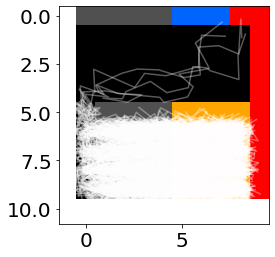

In [357]:
# Plot the trajectories...
plt.figure()
lg_img = np.zeros((10,10,4))
lg_img[...,-1]=1
lg_img = build_lg_image(lg_img)
plt.tight_layout()
plt.imshow(lg_img)
for i_traj in range(1000):
    temp_dict = eval_results[i_traj]
    traj = np.vstack(temp_dict['state'])
    plt.plot(traj[:,0], traj[:,1], '-', color='white', alpha=0.35)
plt.show()

Looks pretty good! Now we just need to evaluate the flags for each trajectory and get a sense of whether the IQN does better (and how much earlier)

In [34]:
temp_dict.keys()

dict_keys(['step', 'state', 'dead_end', 'dqn_dn', 'dqn_rn', 'iqn_dn', 'iqn_rn'])

In [53]:
len(temp_dict['iqn_dn'][0])

20

In [337]:
class th:
    ded_dn_red = -0.25
    ded_rn_red = 0.75

    ded_dn_yel = -0.15
    ded_rn_yel = 0.85

    ded_dn_gry1 = -0.10
    ded_rn_gry1 = 0.90
    
    ded_dn_gry2 = -0.05
    ded_rn_gry2 = 0.95

    new_dn_red = -0.6
    new_rn_red = 0.4

    new_dn_yel = -0.25
    new_rn_yel = 0.75

In [338]:
def compare_ded_red(row):
    return np.logical_and(row['dqn_dn']<th.ded_dn_red, row["dqn_rn"]<th.ded_rn_red)

def compare_ded_yellow(row):
    return np.logical_and(row['dqn_dn']<th.ded_dn_yel, row["dqn_rn"]<th.ded_rn_yel)

def compare_comb_ded_yellow(row):
    return row['comb_dqn']<=th.ded_dn_yel

def compare_red(row):
    return np.logical_and(row['iqn_dn']<th.new_dn_red, row['iqn_rn']<th.new_rn_red)
    
def compare_yellow(row):
    return np.logical_and(row['iqn_dn']<th.new_dn_yel, row['iqn_rn']<th.new_rn_yel)

def compare_comb_yellow(row):
    return row['comb_iqn'] < th.new_dn_yel

In [339]:
def create_analysis_df(results, num_trajectories):
    data = {'traj': [], 'step': [], 'iqn_dn': [], 'iqn_rn': [], 'dqn_dn': [], 'dqn_rn': [], 'dead_end': [], 'location': [], 'comb_dqn': [], 'comb_iqn': []}
    
    for i_traj in range(num_trajectories):
        traj_states = results[i_traj]['state']
        traj_iqn_qd = np.vstack(results[i_traj]['iqn_dn'])
        traj_iqn_qr = np.vstack(results[i_traj]['iqn_rn'])
        traj_dqn_qd = np.vstack(results[i_traj]['dqn_dn'])
        traj_dqn_qr = np.vstack(results[i_traj]['dqn_rn'])
        traj_de = results[i_traj]['dead_end']
        
        # Average over aligned values assessed from both Q_D and Q_R
        comb_vals_iqn = np.mean(np.concatenate([np.clip(traj_iqn_qd,-1.,0.)[...,None], (np.clip(traj_iqn_qr,0., 1.0)-1.)[...,None]], axis=-1),  axis=-1)
        comb_vals_dqn = np.mean(np.concatenate([np.clip(traj_dqn_qd,-1.,0.)[...,None], (np.clip(traj_dqn_qr,0., 1.0)-1.)[...,None]], axis=-1),  axis=-1)
        
        for i_step in range(len(traj_states)):
            data['traj'].append(i_traj)
            data['step'].append(i_step)
            data['location'].append(traj_states[i_step])
            data['dead_end'].append(traj_de[i_step])
            data['iqn_dn'].append(traj_iqn_qd[i_step])
            data['iqn_rn'].append(traj_iqn_qr[i_step])
            data['comb_iqn'].append(comb_vals_iqn[i_step])
            data['dqn_dn'].append(traj_dqn_qd[i_step])
            data['dqn_rn'].append(traj_dqn_qr[i_step])
            data['comb_dqn'].append(comb_vals_dqn[i_step])

    return pd.DataFrame(data)

In [340]:
analysis_df = create_analysis_df(eval_results, 1000)

In [341]:
def assess_flags(values_df, num_trajectories):
    data = {'traj': [], 'fst_de': [], 'dqn_flag': [], 'iqn_flags': []}
    
    for i_traj in range(num_trajectories):
        df = values_df[values_df.traj==i_traj]
        
        dqn_flags = np.vstack(df.apply(compare_comb_ded_yellow, axis=1).values)
        iqn_flags = np.vstack(df.apply(compare_comb_yellow, axis=1).values)
        
        des = df.dead_end.values
        step = df.step.values
        
        first_de = (des*step)
        try:
            first_de = first_de[np.nonzero(first_de)][0]
        except:  # Need to account for arrays that don't reach a dead-end...
            first_de = None
            
        try:
            dqn_fst_flg = np.where(dqn_flags==True)[0][0]  # Get the step where the first flag is raised for the DQN
        except:
            dqn_fst_flg = None # Account for when DQN doesn't raise a flag (unlikely for great majority of trajectories)
            
        first_flags_iqn = []
        
        # Pull off information from IQN value functions
        for ii in range(20): # We only evaluated 20 settings of VaR
            try:
                fst_flg = np.where(iqn_flags==True)[0][0]  # Get the step where the first flag is raised for the IQN
            except:
                fst_flg = None # Account for when IQN doesn't raise a flag (unlikely)
                
            first_flags_iqn.append(fst_flg)
            
        data['traj'].append(i_traj)
        data['fst_de'].append(first_de)
        data['dqn_flag'].append(dqn_fst_flg)
        data['iqn_flags'].append(first_flags_iqn)
        
    return pd.DataFrame(data)
            

In [342]:
flags_df = assess_flags(analysis_df, 1000)

In [343]:
flags_df.head()

,traj,fst_de,dqn_flag,iqn_flags
0,0,7.0,6.0,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
1,1,5.0,4.0,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
2,2,3.0,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,9.0,5.0,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
4,4,5.0,4.0,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ..."


In [344]:
# Remove the few trajectories that didn't ever reach the dead-end region (removes complications with DQN flags not being raised...)
flags_df = flags_df[~flags_df.fst_de.isnull()]

### Now cycle through all trajectories (and flags) to calculate the timesteps ahead of Dead-end 
(and timesteps that IQN is ahead of DQN)

In [345]:
diff_in_flags = []
iqn_ts_ahead_de = []
dqn_ts_ahead_de = []

for traj in flags_df.traj.values:
    traj_flag_diffs = []
    traj_iqn_v_de = []
    
    fst_de = flags_df.loc[traj]['fst_de']
    
    # Extract the DQN flag and compute how 'early' it is relative to the Dead-end region
    dqn_flag_ts = flags_df.loc[traj]['dqn_flag']
    dqn_ts_ahead_de.append(fst_de - dqn_flag_ts)
    
    for ivar in range(20):
        ivar_flag_ts = flags_df.loc[traj]['iqn_flags'][ivar]
        
        # Record, for each VaR setting, how much earlier the IQN flags the trajectory
        #  as well as how far ahead of the DE region...
        if ivar_flag_ts is None:
            traj_flag_diffs.append(np.nan)
            traj_iqn_v_de.append(0)
        else:
            traj_flag_diffs.append(dqn_flag_ts - ivar_flag_ts)
            traj_iqn_v_de.append(fst_de - ivar_flag_ts)
            
    diff_in_flags.append(traj_flag_diffs)
    iqn_ts_ahead_de.append(traj_iqn_v_de)

In [346]:
diff_in_flags = np.vstack(diff_in_flags)
iqn_ts_ahead_de = np.vstack(iqn_ts_ahead_de)
dqn_ts_ahead_de = np.vstack(dqn_ts_ahead_de)

In [347]:
diff_in_flags.shape, iqn_ts_ahead_de.shape, dqn_ts_ahead_de.shape

((996, 20), (996, 20), (996, 1))

In [348]:
mean_diffs_in_flags = np.nanmean(diff_in_flags, axis=0)
mean_ts_ahead = np.nanmean(iqn_ts_ahead_de, axis=0)

In [349]:
VaR_thresholds =  np.round(np.linspace(0.05, 1.0, num=20), decimals=2)

In [350]:
print("The avg. number of steps DistDeD flags a trajectory before DeD...")
for ii, ivar in enumerate(VaR_thresholds):
    print(f"For CVaR = {ivar}... ahead of DeD: {mean_diffs_in_flags[ii]:.3f} || ahead of DE: {mean_ts_ahead[ii]:.3f}")

The avg. number of steps DistDeD flags a trajectory before DeD...
For CVaR = 0.05... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.1... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.15... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.2... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.25... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.3... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.35... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.4... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.45... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.5... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.55... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.6... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.65... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.7... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.75... ahead of DeD: 2.227 || ahead of DE: 4.064
For CVaR = 0.8... ahead of

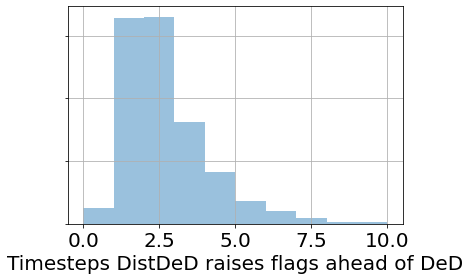

In [355]:
plt.hist(diff_in_flags.flatten(), density=True, label="DistDeD - DeD", alpha=0.45)
plt.grid()
plt.xlabel("Timesteps DistDeD raises flags ahead of DeD")
ax = plt.gca()
ax.set_yticklabels('')
plt.show()

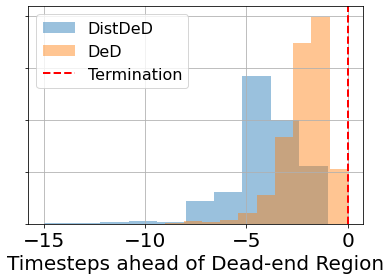

In [365]:
plt.figure(figsize=(6,4))
plt.hist(-1.0 * iqn_ts_ahead_de.flatten(), alpha=0.45, density=True, label='DistDeD')
plt.hist(-1.0 * dqn_ts_ahead_de, alpha=0.45, density=True, label='DeD')
plt.axvline(0, lw=2, color='red', linestyle='--', label="Termination")
plt.grid()
plt.legend(fontsize=16)
plt.xlabel("Timesteps ahead of Dead-end Region")
ax = plt.gca()
ax.set_yticklabels('')
plt.show()

## Plot all actions for Q_R and Q_D

#### Not currently configured for IQN results

TBD

In [122]:
np.max(dqn_ts_ahead_de)

9.0

In [15]:
# Stay put (action 0)
plt.figure()
plt.imshow(q_d[...,0],vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.show()

/var/folders/7v/fm3pt5g52zq3ww39c6s0cnjc0000gn/T/ipykernel_26238/267373473.py:5: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [20]:
# Go Up (action 1)
plt.figure()
plt.imshow(q_d[...,1],vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.show()

/Users/taylor/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  """


In [21]:
# Go Down (action 2)
plt.figure()
plt.imshow(q_d[...,2],vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.show()

/Users/taylor/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  """


In [22]:
# Go Left (action 3)
plt.figure()
plt.imshow(q_d[...,3],vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.show()

/Users/taylor/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  """


In [23]:
# Go Right (action 4)
plt.figure()
plt.imshow(q_d[...,4],vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.show()

/Users/taylor/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  """


In [24]:
# Stay Put (action 0)
plt.figure()
plt.imshow(q_r[...,0],vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.show()

/Users/taylor/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  """


In [25]:
# Go Up (action 1)
plt.figure()
plt.imshow(q_r[...,1],vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.show()

/Users/taylor/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  """


In [26]:
# Go Down (action 2)
plt.figure()
plt.imshow(q_r[...,2],vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.show()

/Users/taylor/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  """


In [27]:
# Go Left (action 3)
plt.figure()
plt.imshow(q_r[...,3],vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.show()

/Users/taylor/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  """


In [28]:
# Go Right (action 4)
plt.figure()
plt.imshow(q_r[...,4],vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.show()

/Users/taylor/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  """


## PLOT ACTION-VALUE DISTRIBUTIONS

In [371]:
num_samples = 1000

In [466]:
# Get state tuple into numpy -> torch format
# inp_state = torch.from_numpy(np.array([2, 9]).reshape((1,-1))).float().to(device)
# inp_state = torch.from_numpy(np.array([5, 7]).reshape((1,-1))).float().to(device)
inp_state = torch.from_numpy(np.array([6, 2]).reshape((1,-1))).float().to(device)
# inp_state = torch.from_numpy(np.array([7, 7]).reshape((1, -1))).float().to(device)


# Pass state through the IQN and DQN networks
iqn_d_vals, taus_d = iqn_d.forward(inp_state, num_samples, use_drm=False)
iqn_d_vals_drm, taus_d_drm = iqn_d.forward(inp_state, num_samples, use_drm=True)

iqn_r_vals, taus_r = iqn_r.forward(inp_state, num_samples, use_drm=False)
iqn_r_vals_drm, taus_r_drm = iqn_r.forward(inp_state, num_samples, use_drm=True)

dqn_d_vals = dqn_d.forward(inp_state)
dqn_r_vals = dqn_r.forward(inp_state)

In [467]:
iqn_d_vals.shape

torch.Size([1, 1000, 5])

In [468]:
iqn_r_vals.shape

torch.Size([1, 1000, 5])

In [469]:
dqn_d_vals = dqn_d_vals.detach().squeeze().numpy()

In [470]:
data = iqn_d_vals.detach().squeeze().numpy()
data_drm = iqn_d_vals_drm.detach().squeeze().numpy()
# Sort the data to get the .9 conf VaR (take the max of the first 100 points)
data = np.sort(data, axis=0)
data_var = data[:100,:]

In [471]:
df = pd.DataFrame(data)
df_drm = pd.DataFrame(data_drm)
df_var = pd.DataFrame(data_var)

In [472]:
df2 = pd.melt(df, value_vars=[0, 1, 2, 3, 4], var_name="action")
df2['drm'] = "Full"
# df2_drm = pd.melt(df_drm, value_vars=[0, 1, 2, 3, 4], var_name="action")
# df2_drm['drm'] = "DRM"
df2_var = pd.melt(df_var, value_vars=[0, 1, 2, 3, 4], var_name="action")
df2_var['drm'] = "VaR"

In [473]:
# big_df = pd.concat([df2, df2_drm, df2_var], axis=0).reset_index(drop=True)
big_df = pd.concat([df2, df2_var], axis=0).reset_index(drop=True)
big_df.shape
big_df['dummy'] = 0
big_df.head()

,action,value,drm,dummy
0,0,-0.766472,Full,0
1,0,-0.764220,Full,0
2,0,-0.745591,Full,0
3,0,-0.718221,Full,0
4,0,-0.699586,Full,0


In [474]:
plt.rcParams.update({'font.size': 20})

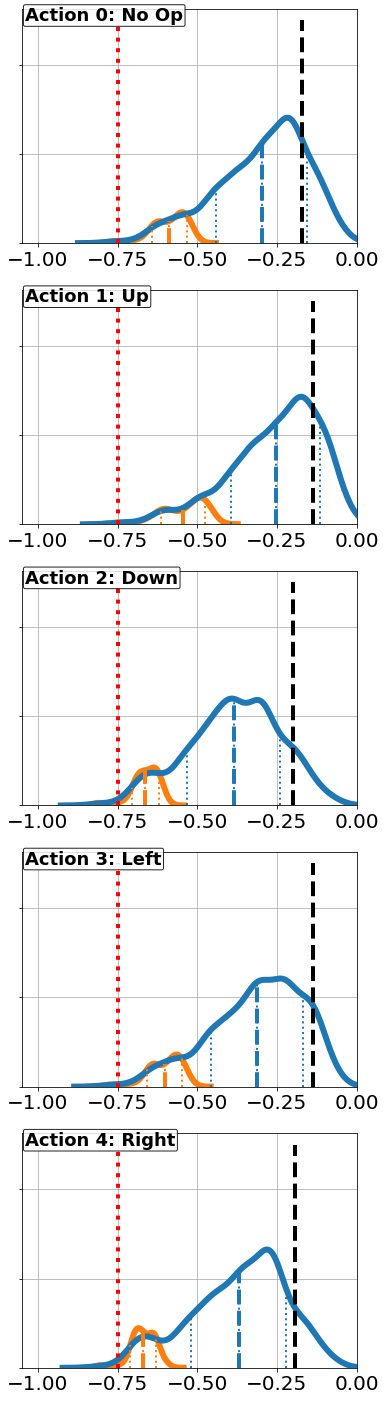

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

In [475]:
# types = ['VaR', 'DRM', 'Full']
types = ['VaR', 'Full']
colors = sns.color_palette(n_colors=2)[::-1]
actions = ['No Op', 'Up', 'Down', 'Left', 'Right']

fig, axs = plt.subplots(5, figsize=(6,25))

for act in range(5):
    temp = big_df[big_df.action==act]
    
    var_var = np.var(temp[temp.drm=='VaR']['value'].values)

    plt.figure()
    g = sns.kdeplot(data=temp, x='value',lw=6, hue='drm', legend=False, ax=axs[act], )
    ax = g.axes
    for ii, typ in enumerate(types):
        data = temp[temp.drm==typ]['value'].values
        xs, ys = ax.get_lines()[ii].get_data()
        median = np.median(data)
        mean = data.mean()
        sdev = data.std()
        ax.vlines([mean-sdev, mean, mean+sdev], 0, np.interp([mean-sdev, mean, mean+sdev], xs, ys), color=colors[ii], ls=':', lw=2)
        ax.vlines(mean, 0, np.interp(mean, xs, ys), color=colors[ii], ls='--', lw=4)
    ax.vlines([dqn_d_vals[act]], 0, 5.0, color='black', ls='--', lw=4)
    
    ax.vlines(-0.75, 0, 5.0, color='red', ls=':', lw=4)

    axs[act].grid()
    axs[act].set_xlim([-1.05, 0])
#     axs[act].tick_params(labelsize=14)
    axs[act].set_yticklabels('')
    axs[act].set_ylabel('', fontsize=16)
    axs[act].set_xlabel('', fontsize=16) 
    axs[act].text(0.01, 0.95, 'Action {}: {}'.format(act, actions[act]), transform=ax.transAxes, size=18, weight='bold', bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.85))
#     axs[act].text(0.01, 0.8, 'VaR Variance: {}'.format(var_var), transform=ax.transAxes, size=16)
    
plt.show()

In [115]:
# plt.figure()
# sns.catplot(
#     data=big_df, y='dummy', x="value", orient='h',
#     hue='drm', kind='violin', sharex=False,
#     col='action',col_wrap=1, height=5, aspect=1.5)
# plt.show()

In [116]:
# plt.figure()
# g = sns.displot(kind='kde', data=df2, x='value', 
#                 col='action', col_wrap=1, height=4, 
#                 aspect=3,lw=4)

# for act, ax in g.axes_dict.items():
#     dat = df2[df2['action'] == act]['value'].values
#     xs, ys = ax.get_lines()[0].get_data()
#     median = np.median(dat)
#     dqn_mean = dqn_d_vals[i]
#     mean = dat.mean()
#     sdev = dat.std()
#     ax.vlines([mean-sdev, mean, mean+sdev], 0, np.interp([mean-sdev, mean, mean+sdev], xs, ys), color='b', ls=':', lw=2)
#     ax.vlines(median, 0, np.interp(median, xs, ys), color='r', ls='--', lw=4)
#     ax.vlines(dqn_mean, 0, np.interp(dqn_mean, xs, ys), color='k',ls='-.', lw=4)
# plt.xlim([-1, 0])
# plt.tight_layout()
# plt.show()

In [117]:
# plt.figure()
# h = sns.displot(kind='kde', data=df2_drm, x='value', 
#                 col='action', col_wrap=1, height=4, 
#                 aspect=3, lw=4, color='purple')

# for act, ax in h.axes_dict.items():
#     dat = df2_drm[df2_drm['action'] == act]['value'].values
#     xs, ys = ax.get_lines()[0].get_data()
#     median = np.median(dat)
#     dqn_mean = dqn_d_vals[i]
#     mean = dat.mean()
#     sdev = dat.std()
#     ax.vlines([mean-sdev, mean, mean+sdev], 0, np.interp([mean-sdev, mean, mean+sdev], xs, ys), color='purple', ls=':', lw=2)
#     ax.vlines(median, 0, np.interp(median, xs, ys), color='purple', ls='--', lw=4)
#     ax.vlines(dqn_mean, 0, np.interp(dqn_mean, xs, ys), color='k',ls='-.', lw=4)
# plt.xlim([-1, 0])
# plt.tight_layout()
# plt.show()

In [118]:
# plt.figure()
# h = sns.displot(kind='kde', data=df2_var, x='value', 
#                 col='action', col_wrap=1, height=4, 
#                 aspect=3, lw=4, color='green')

# for act, ax in h.axes_dict.items():
#     dat = df2_var[df2_var['action'] == act]['value'].values
#     xs, ys = ax.get_lines()[0].get_data()
#     median = np.median(dat)
#     dqn_mean = dqn_d_vals[i]
#     mean = dat.mean()
#     sdev = dat.std()
#     ax.vlines([mean-sdev, mean, mean+sdev], 0, np.interp([mean-sdev, mean, mean+sdev], xs, ys), color='b', ls=':', lw=2)
#     ax.vlines(median, 0, np.interp(median, xs, ys), color='r', ls='--', lw=4)
#     ax.vlines(dqn_mean, 0, np.interp(dqn_mean, xs, ys), color='k',ls='-.', lw=4)
# plt.xlim([-1, 0])
# plt.tight_layout()
# plt.show()